## 이미지 다루기

In [1]:
import cv2
import numpy as np
import math

point4 = []
origin_img = cv2.imread('card.jpg')
color = (0,255,0)

def mouse_handler(event, x, y, flag, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        if len(point4) < 4:
            point4.append((x, y))
        if len(point4) == 4:
            show_result()
    if len(point4) < 4:
        display_img = origin_img.copy()
        for p in point4:
            cv2.circle(display_img, p, 5, color, cv2.FILLED)
        for i in range(len(point4) - 1):
            cv2.line(display_img, point4[i], point4[i+1], color, 2)
        if event == cv2.EVENT_MOUSEMOVE and len(point4) > 0:
            cv2.line(display_img, point4[-1], (x,y), color, 1, cv2.LINE_AA)
        cv2.imshow('img', display_img)

def distance(p1,p2):
    return math.sqrt((p1[0]-p2[0])**2+(p1[1]-p2[1])**2)

def show_result():
    src = np.float32(point4)
    width = int(max(distance(src[0], src[1]), distance(src[2], src[3])))
    height = int(max(distance(src[0], src[3]), distance(src[1], src[2])))

    dst = np.array([[0,0], [width,0], [width,height], [0,height]], dtype=np.float32)
    matrix = cv2.getPerspectiveTransform(src, dst)
    res = cv2.warpPerspective(origin_img, matrix, (width,height))
    cv2.imshow('result', res)
cv2.namedWindow('img')
cv2.setMouseCallback('img', mouse_handler)
cv2.imshow('img', origin_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [16]:
import cv2
color = cv2.imread('cat.jpg', cv2.IMREAD_COLOR)
gray = cv2.imread('cat.jpg', cv2.IMREAD_GRAYSCALE)
unchange = cv2.imread('cat.jpg', cv2.IMREAD_UNCHANGED)
cv2.imshow('color', color)
cv2.imshow('gray', gray)
cv2.imshow('unchange', unchange)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1)

-1

In [17]:
# 이미지 저장
# cv2.imwrite('sam01.jpg', color)

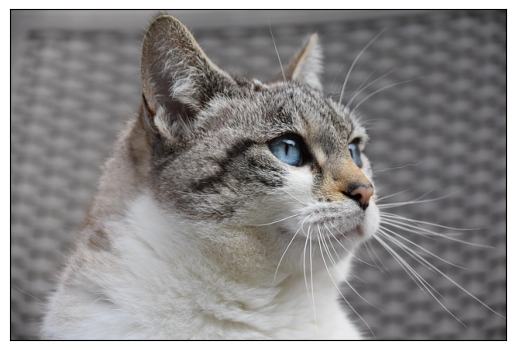

In [21]:
#-*- coding:utf-8 -*-
import cv2
from matplotlib import pyplot as plt
img = cv2.imread('cat.jpg', cv2.IMREAD_COLOR)

b,g,r = cv2.split(img)  # img파일을 b,g,r로 분리
img2 = cv2.merge([r,g,b])  # b,r을 바꿔서 Merge

# plt.imshow(img)
plt.imshow(img2)
plt.xticks([])
plt.yticks([])
plt.show()

## 영상 다루기

In [ ]:
# -*-coding: utf-8 -*-
import cv2

# cap 이 정상적으로 open이 되었는지 확인하기 위해서 cap.isOpen() 으로 확인가능
cap = cv2.VideoCapture(0) # 0은 화상카메라일때 사용

# cap.get(prodId)/cap.set(propId, value)을 통해서 속성 변경이 가능.
# 3은 width, 4는 heigh

print 'width: {0}, height: {1}'.format(cap.get(3),cap.get(4))
cap.set(3,320)
cap.set(4,240)

while(True):
    # ret : frame capture결과(boolean)
    # frame : Capture한 frame
    ret, frame = cap.read()

    if (ret):
        # image를 Grayscale로 Convert함.
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        cv2.imshow('frame', gray)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

In [23]:
import cv2

cap = cv2.VideoCapture('cat.mp4')

while(cap.isOpened()):
    ret, frame = cap.read()

    # 프레임을 제대로 못 읽어왔다면 루프 종료
    if not ret:
        print("프레임을 수신할 수 없습니다. 종료합니다.")
        break
        
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    cv2.imshow('frame',gray)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

프레임을 수신할 수 없습니다. 종료합니다.


### 1. ret의 역할 (Boolean 값)
- True: 카메라에서 프레임(이미지 데이터)을 성공적으로 읽어왔을 때 반환됩니다.
- False: 영상 파일이 끝났거나, 카메라 연결이 끊겼거나, 어떤 이유로든 프레임을 가져오지 못했을 때 반환됩니다.
### 2. 왜 ret를 쓰나요?
- 실제 코드에서는 ret가 False일 때 루프를 빠져나가거나 오류 처리를 하기 위해 사용합니다. 예를 들어 다음과 같이 작성하는 것이 더 안전합니다.

In [ ]:
import cv2
cap = cv2.VideoCapture('cat.mp4')
while(cap.isopened()):
    ret, frame = cap.read()
    

In [ ]:
# -*-coding: utf-8 -*-

import cv2

cap = cv2.VideoCapture(0) # 화상카메라의 영상을 저장하는듯

fourcc = cv2.VideoWriter_fourcc(*'DIVX')
out = cv2.ViewoWriter('output.avi', fourcc, 25.0, (640,480))
# cv2.VideoWriter(outputFile, fourcc, frame, size)
# Parameters:	
# outputFile (str) – 저장될 파일명
# fourcc – Codec정보. cv2.VideoWriter_fourcc()
# frame (float) – 초당 저장될 frame
# size (list) – 저장될 사이즈(ex; 640, 480)

while (cap.isOpend()):
    ret, frame = cap.read()

    if ret:
        # 이미지 반전,  0:상하, 1 : 좌우
        frame = cv2.flip(frame, 0)

        out.write(frame)

        cv2.imshow('frame', frame)

        if cv2.waitKey(0) & 0xFF == ord('q'):
            break
    else:
        break

cap.release()
out.release()
cv2.destroyAllWindows()

## 도형 다루기

### cv2.line(img, start, end, color, thickness)
Parameters:	
- img – 그림을 그릴 이미지 파일
- start – 시작 좌표(ex; (0,0))
- end – 종료 좌표(ex; (500. 500))
- color – BGR형태의 Color(ex; (255, 0, 0) -> Blue)
- thickness (int) – 선의 두께. pixel

### cv2.rectangle(img, start, end, color, thickness)
Parameters:	
- img – 그림을 그릴 이미지
- start – 시작 좌표(ex; (0,0))
- end – 종료 좌표(ex; (500. 500))
- color – BGR형태의 Color(ex; (255, 0, 0) -> Blue)
- thickness (int) – 선의 두께. pixel

### cv2.circle(img, center, radian, color, thickness)
Parameters:	
- img – 그림을 그릴 이미지
- center – 원의 중심 좌표(x, y)
- radian – 반지름
- color – BGR형태의 Color
- thickness – 선의 두께, -1 이면 원 안쪽을 채움

### cv2.ellipse(img, center, axes, angle, startAngle, endAngle, color[, thickness[, lineType[, shift]]]) → img
Parameters:	
- img – image
- center – 타원의 중심
- axes – 중심에서 가장 큰 거리와 작은 거리
- angle – 타원의 기울기 각
- startAngle – 타원의 시작 각도
- endAngle – 타원이 끝나는 각도
- color – 타원의 색
- thickness – 선 두께 -1이면 안쪽을 채움

### cv2.polylines(img, pts, isClosed, color, thickness)
Parameters:	
- img – image
- pts (array) – 연결할 꼭지점 좌표
- isClosed – 닫흰 도형 여부
- color – Color
- thickness – 선 두께

### cv2.putText(img, text, org, font, fontSacle, color)
Parameters:	
- img – image
- text – 표시할 문자열
- org – 문자열이 표시될 위치. 문자열의 bottom-left corner점
- font – font type. CV2.FONT_XXX
- fontSacle – Font Size
- color – fond color